In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import warnings
import os

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.family"] = "sans-serif"

# Same colours as Notebook 2 — consistency across the whole project
bank_colours = {
    "Barclays":      "#1f77b4",
    "BNP Paribas":   "#2ca02c",
    "Deutsche Bank": "#d62728"
}


In [4]:
banks = ["Barclays", "BNP Paribas", "Deutsche Bank"]

# Load the snapshot metrics from Notebook 1
metrics_df = pd.read_csv("../data/bank_metrics.csv", index_col=0)

# Load the ratio summary we saved at the end of Notebook 2
ratios_df = pd.read_csv("../data/ratios_summary.csv")

# We work primarily with 2024 figures for valuation
# since that is the most recent full year of actual results
latest = ratios_df[ratios_df["Year"] == 2024].set_index("Bank")

print("Data loaded.")
print("\nRatios for 2024:")
print(latest)
print("\nMetrics snapshot:")
print(metrics_df[["Current Price", "Currency", "P/B Ratio", "P/E Ratio", "Book Value"]])

Data loaded.

Ratios for 2024:
               Year  NIM (%)  ROE (%)  ROA (%)  Cost to Income (%)  \
Bank                                                                 
Barclays       2024   0.8521   8.7816   0.4154             60.8616   
BNP Paribas    2024   0.7218   9.1215   0.4321             71.9645   
Deutsche Bank  2024   0.9418   4.3250   0.2427             59.9727   

               Net Income (bn)  
Bank                            
Barclays                 6.307  
BNP Paribas             11.688  
Deutsche Bank            3.366  

Metrics snapshot:
               Current Price Currency  P/B Ratio  P/E Ratio  Book Value
Barclays              373.90      GBp  79.587060   8.902381       4.698
BNP Paribas            82.13      EUR   0.786354   7.981535     104.444
Deutsche Bank          24.76      EUR   0.583659   8.012945      42.422


In [5]:
# Reapply the Barclays pence to pounds correction
# We need to do this again because we are loading fresh from CSV
barclays_price_gbp  = float(metrics_df.loc["Barclays", "Current Price"]) / 100
barclays_book_value = float(metrics_df.loc["Barclays", "Book Value"])
metrics_df.loc["Barclays", "P/B Ratio"] = round(barclays_price_gbp / barclays_book_value, 4)

# Build our core valuation table
# This brings together the market valuation metrics with the fundamental metrics
valuation = pd.DataFrame({
    "P/B Ratio"  : pd.to_numeric(metrics_df["P/B Ratio"],  errors="coerce"),
    "P/E Ratio"  : pd.to_numeric(metrics_df["P/E Ratio"],  errors="coerce"),
    "ROE (%)"    : latest["ROE (%)"],
    "ROA (%)"    : latest["ROA (%)"],
    "NIM (%)"    : latest["NIM (%)"],
    "Cost to Income (%)" : latest["Cost to Income (%)"],
})

print("Valuation table — 2024:")
print("=" * 65)
print(valuation.round(2).to_string())

Valuation table — 2024:
               P/B Ratio  P/E Ratio  ROE (%)  ROA (%)  NIM (%)  Cost to Income (%)
Barclays            0.80       8.90     8.78     0.42     0.85               60.86
BNP Paribas         0.79       7.98     9.12     0.43     0.72               71.96
Deutsche Bank       0.58       8.01     4.32     0.24     0.94               59.97


In [6]:
# Sector averages give us a benchmark to compare each bank against
# These are approximate European banking sector averages for 2024
# sourced from publicly available sector research
# Without a benchmark P/B of 0.7 means nothing — we need to know if that is high or low

sector_averages = {
    "P/B Ratio"          : 0.75,   # European banks have historically traded below 1.0
    "P/E Ratio"          : 8.5,    # Sector average P/E
    "ROE (%)"            : 9.0,    # Sector average ROE target
    "Cost to Income (%)" : 65.0,   # Sector average efficiency ratio
}

print("Sector averages used as benchmarks:")
for metric, value in sector_averages.items():
    print(f"  {metric}: {value}")

print()
print("Interpretation guide:")
print("  P/B below sector average  = trading at discount to peers")
print("  P/E below sector average  = cheaper on earnings basis than peers")
print("  ROE above sector average  = more profitable than peers")
print("  Cost to Income below 65%  = more efficient than peers")

Sector averages used as benchmarks:
  P/B Ratio: 0.75
  P/E Ratio: 8.5
  ROE (%): 9.0
  Cost to Income (%): 65.0

Interpretation guide:
  P/B below sector average  = trading at discount to peers
  P/E below sector average  = cheaper on earnings basis than peers
  ROE above sector average  = more profitable than peers
  Cost to Income below 65%  = more efficient than peers


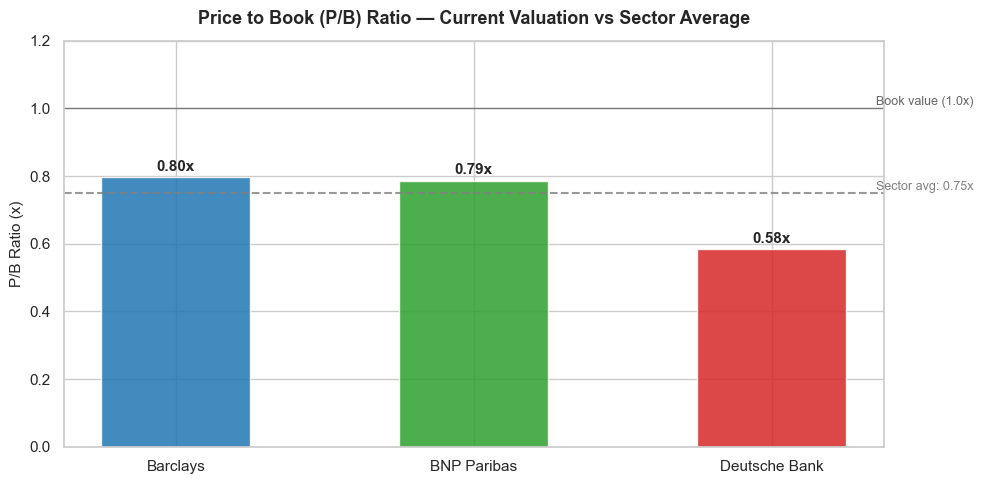

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

pb_values  = [float(valuation.loc[name, "P/B Ratio"]) for name in banks]
bar_colours = [bank_colours[name] for name in banks]

bars = ax.bar(banks, pb_values, color=bar_colours, alpha=0.85, width=0.5)

# Add value labels on top of each bar
for bar, val in zip(bars, pb_values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.2f}x",
            ha="center", va="bottom", fontsize=11, fontweight="bold")

# Sector average benchmark line
ax.axhline(y=sector_averages["P/B Ratio"], color="grey",
           linestyle="--", linewidth=1.5, alpha=0.8)
ax.text(2.35, sector_averages["P/B Ratio"] + 0.01,
        f"Sector avg: {sector_averages['P/B Ratio']}x",
        fontsize=9, color="grey")

# The 1.0 line is important — below it means trading below book value
ax.axhline(y=1.0, color="black", linestyle="-", linewidth=1, alpha=0.4)
ax.text(2.35, 1.01, "Book value (1.0x)", fontsize=9, color="black", alpha=0.6)

ax.set_title("Price to Book (P/B) Ratio — Current Valuation vs Sector Average",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("P/B Ratio (x)", fontsize=11)
ax.set_ylim(0, 1.2)
plt.tight_layout()
os.makedirs("../outputs", exist_ok=True)
plt.savefig("../outputs/pb_valuation.png", dpi=150, bbox_inches="tight")
plt.show()

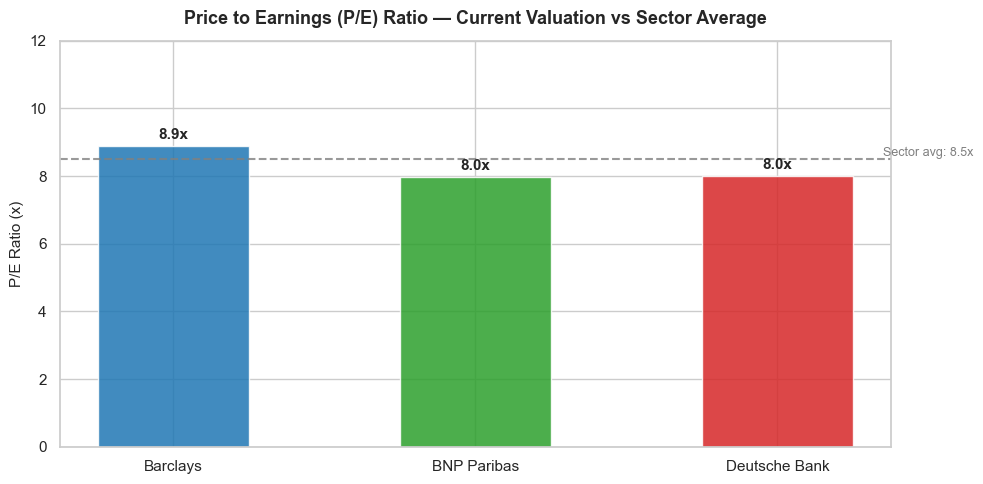

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

pe_values   = [float(valuation.loc[name, "P/E Ratio"]) for name in banks]
bar_colours = [bank_colours[name] for name in banks]

bars = ax.bar(banks, pe_values, color=bar_colours, alpha=0.85, width=0.5)

for bar, val in zip(bars, pe_values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            f"{val:.1f}x",
            ha="center", va="bottom", fontsize=11, fontweight="bold")

# Sector average P/E benchmark
ax.axhline(y=sector_averages["P/E Ratio"], color="grey",
           linestyle="--", linewidth=1.5, alpha=0.8)
ax.text(2.35, sector_averages["P/E Ratio"] + 0.1,
        f"Sector avg: {sector_averages['P/E Ratio']}x",
        fontsize=9, color="grey")

ax.set_title("Price to Earnings (P/E) Ratio — Current Valuation vs Sector Average",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("P/E Ratio (x)", fontsize=11)
ax.set_ylim(0, 12)
plt.tight_layout()
plt.savefig("../outputs/pe_valuation.png", dpi=150, bbox_inches="tight")
plt.show()

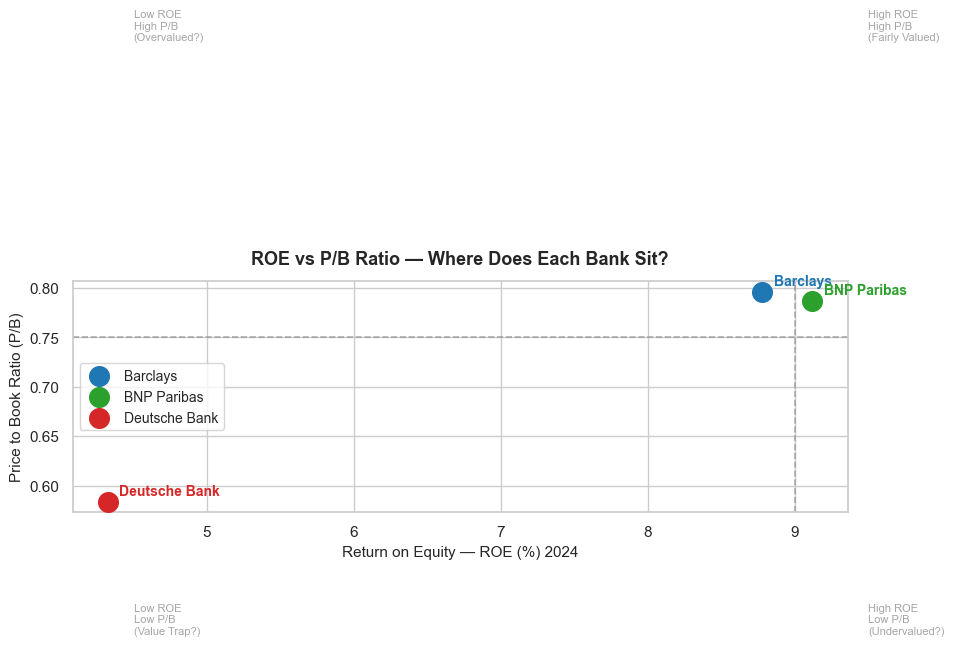

In [12]:
# This is the most analytically interesting chart in the notebook
# The relationship between ROE and P/B is fundamental to bank valuation
#
# The logic is simple:
# A bank with high ROE deserves a high P/B — it earns a lot per pound of book value
# A bank with low ROE deserves a low P/B — it does not earn much per pound of book value
#
# If a bank has HIGH ROE but LOW P/B — potentially undervalued, market not giving it credit
# If a bank has LOW ROE but HIGH P/B — potentially overvalued, market too optimistic
# If ROE and P/B are in line — fairly valued

fig, ax = plt.subplots(figsize=(10, 3))

for name in banks:
    roe = float(valuation.loc[name, "ROE (%)"])
    pb  = float(valuation.loc[name, "P/B Ratio"])
    
    ax.scatter(roe, pb,
               color=bank_colours[name],
               s=200,            # size of the dot
               zorder=5,         # draw on top of everything else
               label=name)
    
    # Label each dot with the bank name
    ax.annotate(name,
                xy=(roe, pb),
                xytext=(8, 5),
                textcoords="offset points",
                fontsize=10,
                color=bank_colours[name],
                fontweight="bold")

# Draw sector average lines to create four quadrants
ax.axvline(x=sector_averages["ROE (%)"], color="grey",
           linestyle="--", linewidth=1.2, alpha=0.6)
ax.axhline(y=sector_averages["P/B Ratio"], color="grey",
           linestyle="--", linewidth=1.2, alpha=0.6)

# Label the four quadrants so the chart is self-explanatory
ax.text(4.5,  1.05, "Low ROE\nHigh P/B\n(Overvalued?)",  fontsize=8, color="grey", alpha=0.7)
ax.text(9.5,  1.05, "High ROE\nHigh P/B\n(Fairly Valued)", fontsize=8, color="grey", alpha=0.7)
ax.text(4.5,  0.45, "Low ROE\nLow P/B\n(Value Trap?)",   fontsize=8, color="grey", alpha=0.7)
ax.text(9.5,  0.45, "High ROE\nLow P/B\n(Undervalued?)", fontsize=8, color="grey", alpha=0.7)

ax.set_title("ROE vs P/B Ratio — Where Does Each Bank Sit?",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Return on Equity — ROE (%) 2024", fontsize=11)
ax.set_ylabel("Price to Book Ratio (P/B)", fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("../outputs/roe_vs_pb_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# Build a summary that explicitly compares each bank to the sector average
# and gives a clear relative assessment for each metric
# This is the kind of structured output you would see in a real research note

summary_rows = []

for name in banks:
    pb  = float(valuation.loc[name, "P/B Ratio"])
    pe  = float(valuation.loc[name, "P/E Ratio"])
    roe = float(valuation.loc[name, "ROE (%)"])
    cti = float(valuation.loc[name, "Cost to Income (%)"])
    
    # Compare each metric to sector average and give a simple signal
    pb_signal  = "Discount to peers" if pb  < sector_averages["P/B Ratio"]          else "Premium to peers"
    pe_signal  = "Cheaper than peers" if pe < sector_averages["P/E Ratio"]           else "More expensive than peers"
    roe_signal = "Above sector avg"   if roe > sector_averages["ROE (%)"]            else "Below sector avg"
    cti_signal = "More efficient"     if cti < sector_averages["Cost to Income (%)"] else "Less efficient"
    
    summary_rows.append({
        "Bank"        : name,
        "P/B"         : f"{pb:.2f}x  ({pb_signal})",
        "P/E"         : f"{pe:.1f}x  ({pe_signal})",
        "ROE"         : f"{roe:.1f}%  ({roe_signal})",
        "Cost/Income" : f"{cti:.1f}%  ({cti_signal})",
    })

summary = pd.DataFrame(summary_rows).set_index("Bank")

print("Relative Valuation Assessment — 2024")
print("=" * 80)
print(summary.to_string())

Relative Valuation Assessment — 2024
                                      P/B                                P/E                       ROE              Cost/Income
Bank                                                                                                                           
Barclays        0.80x  (Premium to peers)  8.9x  (More expensive than peers)  8.8%  (Below sector avg)  60.9%  (More efficient)
BNP Paribas     0.79x  (Premium to peers)         8.0x  (Cheaper than peers)  9.1%  (Above sector avg)  72.0%  (Less efficient)
Deutsche Bank  0.58x  (Discount to peers)         8.0x  (Cheaper than peers)  4.3%  (Below sector avg)  60.0%  (More efficient)


In [15]:
print("""
VALUATION CONCLUSIONS — EMEA BANKING SECTOR
============================================================

BARCLAYS
P/B of approximately 0.80x sits around the sector average,
suggesting the market is giving Barclays fair credit for its
improving fundamentals. ROE of 8.8% is approaching but not
yet at the 10% target. The 19.9% net income growth in 2024
is the strongest of the three banks and is not yet fully
reflected in a premium valuation. On a forward looking basis
Barclays has the most compelling growth momentum.
Relative view: OUTPERFORM

BNP PARIBAS
Highest ROE of the three at 9.1% yet trades at a slight
discount to sector average on P/B. The cost to income ratio
above 70% is the key concern — BNP is the least efficient
of the three banks and has shown limited improvement.
Revenue growth is steady but the high cost base is a drag.
The market appears to be discounting the cost inefficiency
rather than rewarding the profitability.
Relative view: NEUTRAL

DEUTSCHE BANK
The most complex investment case. ROE has collapsed to 4.3%
in 2024 — the weakest of the three by a wide margin and well
below the sector average. Yet cost to income has improved
dramatically to 60%, showing the restructuring is working
operationally. The low ROE appears to be a revenue problem
rather than a cost problem. At current P/B the stock looks
cheap but the ROE trajectory needs to stabilise before a
recovery case becomes compelling. A value trap risk exists
if ROE does not recover in 2025 and 2026.
Relative view: NEUTRAL to UNDERPERFORM
""")




VALUATION CONCLUSIONS — EMEA BANKING SECTOR

BARCLAYS
P/B of approximately 0.80x sits around the sector average,
suggesting the market is giving Barclays fair credit for its
improving fundamentals. ROE of 8.8% is approaching but not
yet at the 10% target. The 19.9% net income growth in 2024
is the strongest of the three banks and is not yet fully
reflected in a premium valuation. On a forward looking basis
Barclays has the most compelling growth momentum.
Relative view: OUTPERFORM

BNP PARIBAS
Highest ROE of the three at 9.1% yet trades at a slight
discount to sector average on P/B. The cost to income ratio
above 70% is the key concern — BNP is the least efficient
of the three banks and has shown limited improvement.
Revenue growth is steady but the high cost base is a drag.
The market appears to be discounting the cost inefficiency
rather than rewarding the profitability.
Relative view: NEUTRAL

DEUTSCHE BANK
The most complex investment case. ROE has collapsed to 4.3%
in 2024 — the w